<h2> Fase 0 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Display options ──────────────────────────────────────────────
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ────────────────────────────────────────────────────────
ROOT      = Path("..").resolve()
RAW_DIR   = ROOT / "data" / "raw" / "ieee-fraud-detection"
PROC_DIR  = ROOT / "data" / "processed"

TRANS_CSV = RAW_DIR  / "train_transaction.csv"
IDENT_CSV = RAW_DIR  / "train_identity.csv"
TRANS_PAR = PROC_DIR / "train_transaction.parquet"
IDENT_PAR = PROC_DIR / "train_identity.parquet"

# ── Plotting style ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

In [2]:
# ── Load transactions ────────────────────────────────────────────
if TRANS_PAR.exists():
    trans = pd.read_parquet(TRANS_PAR)
else:
    trans = pd.read_csv(TRANS_CSV)
    trans.to_parquet(TRANS_PAR, index=False)

# ── Load identity ────────────────────────────────────────────────
if IDENT_PAR.exists():
    ident = pd.read_parquet(IDENT_PAR)
else:
    ident = pd.read_csv(IDENT_CSV)
    ident.to_parquet(IDENT_PAR, index=False)

print(f"train_transaction : {trans.shape[0]:,} rows x {trans.shape[1]} cols")
print(f"train_identity    : {ident.shape[0]:,} rows x {ident.shape[1]} cols")

train_transaction : 590,540 rows x 394 cols
train_identity    : 144,233 rows x 41 cols


Legit transactions :    569,877
Fraud transactions :     20,663
Fraud rate         : 3.50%
Imbalance ratio    :  27.6:1  (legit:fraud)


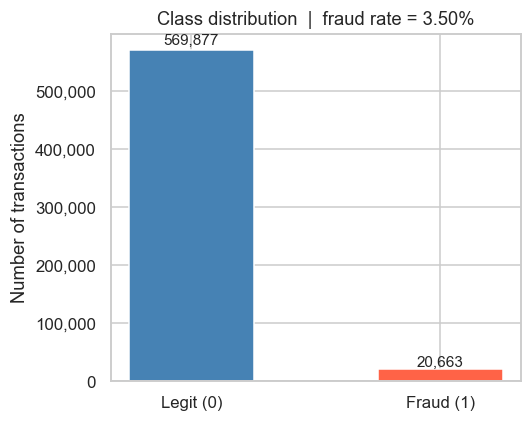

In [ ]:
# ── Class imbalance ──────────────────────────────────────────────
fraud_counts    = trans["isFraud"].value_counts().sort_index()
fraud_rate      = trans["isFraud"].mean()
imbalance_ratio = fraud_counts[0] / fraud_counts[1]

print(f"Legit transactions : {fraud_counts[0]:>10,}")
print(f"Fraud transactions : {fraud_counts[1]:>10,}")
print(f"Fraud rate         : {fraud_rate:.2%}")
print(f"Imbalance ratio    :  {imbalance_ratio:.1f}:1  (legit:fraud)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Legit (0)", "Fraud (1)"], fraud_counts.values,
       color=["steelblue", "tomato"], edgecolor="white", width=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylabel("Number of transactions")
ax.set_title(f"Class distribution  |  fraud rate = {fraud_rate:.2%}")
for bar, val in zip(ax.patches, fraud_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

# - Fraud rate (~3.5% en IEEE-CIS): justifica por qué usamos AUC-PR como métrica principal en lugar de ROC-AUC. Con 3.5% de fraude, un modelo que siempre
#   predice "legit" tiene 96.5% de accuracy — ROC-AUC no lo castiga, AUC-PR sí.
# - Imbalance ratio: te da el número concreto para justificar decisiones de sampling (SMOTE, class weights) en el modelo. Un ratio de ~28:1 es moderado — no
#   necesitás oversampling agresivo, pero sí class_weight en LightGBM.

=== TransactionAmt stats ===
isFraud           0          1
count   569877.0000 20663.0000
mean       134.5117   149.2448
std        239.3951   232.2122
min          0.2510     0.2920
25%         43.9700    35.0440
50%         68.5000    75.0000
75%        120.0000   161.0000
max      31937.3910  5191.0000


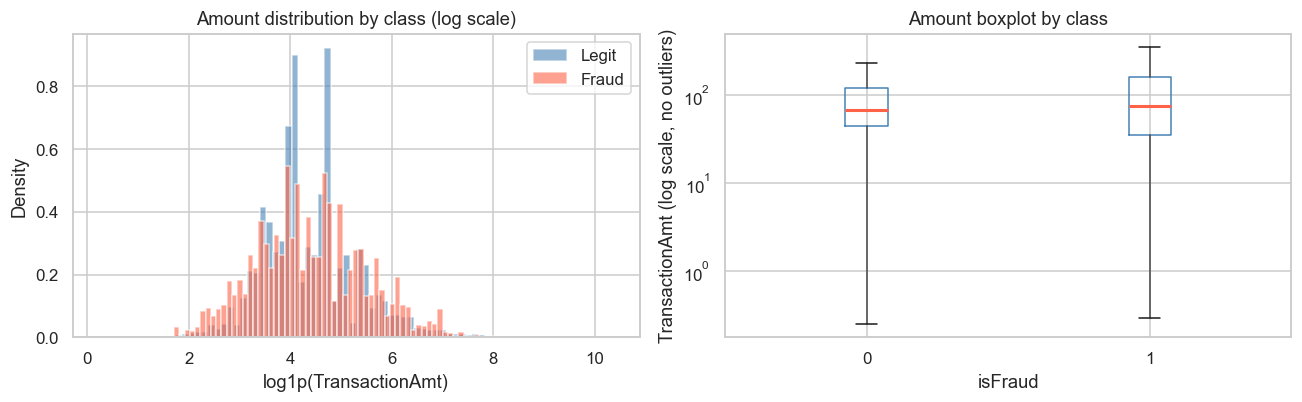

In [4]:
# ── TransactionAmt distribution ──────────────────────────────────
legit_amt = trans.loc[trans["isFraud"] == 0, "TransactionAmt"]
fraud_amt = trans.loc[trans["isFraud"] == 1, "TransactionAmt"]

print("=== TransactionAmt stats ===")
print(trans.groupby("isFraud")["TransactionAmt"].describe().T.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram — log scale on x axis
for amt, label, color in [(legit_amt, "Legit", "steelblue"), (fraud_amt, "Fraud", "tomato")]:
    axes[0].hist(np.log1p(amt), bins=80, alpha=0.6, label=label, color=color, density=True)
axes[0].set_xlabel("log1p(TransactionAmt)")
axes[0].set_ylabel("Density")
axes[0].set_title("Amount distribution by class (log scale)")
axes[0].legend()

# Boxplot
trans.boxplot(column="TransactionAmt", by="isFraud", ax=axes[1],
              boxprops=dict(color="steelblue"),
              medianprops=dict(color="tomato", linewidth=2),
              showfliers=False)
axes[1].set_yscale("log")
axes[1].set_xlabel("isFraud")
axes[1].set_ylabel("TransactionAmt (log scale, no outliers)")
axes[1].set_title("Amount boxplot by class")
plt.suptitle("")
plt.tight_layout()
plt.show()

/var/folders/_s/fjyv9lpx37s1b52z7j2v78gh0000gn/T/ipykernel_33478/3127561506.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trans["hour"] = (trans["TransactionDT"] // 3600) % 24


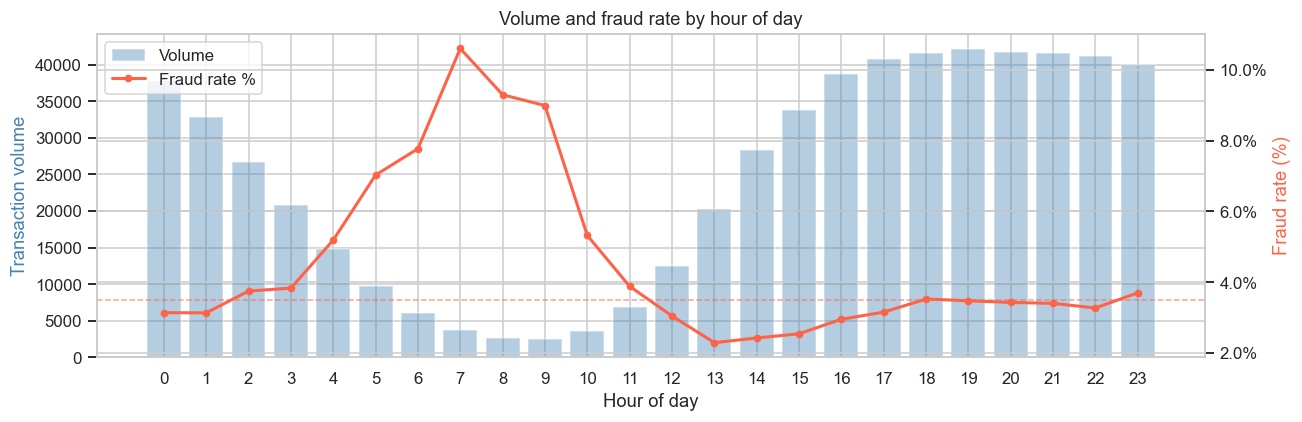

In [6]:
# ── Temporal patterns ────────────────────────────────────────────
# TransactionDT is seconds elapsed since a reference point, not a Unix timestamp.
# We only need hour-of-day, so modular arithmetic is enough — no need to recover the actual date.
trans["hour"] = (trans["TransactionDT"] // 3600) % 24

hourly = trans.groupby("hour").agg(
    volume    = ("isFraud", "count"),
    fraud_rate = ("isFraud", "mean"),
)

fig, ax1 = plt.subplots(figsize=(12, 4))

ax2 = ax1.twinx()
ax1.bar(hourly.index, hourly["volume"], color="steelblue", alpha=0.4, label="Volume")
ax2.plot(hourly.index, hourly["fraud_rate"] * 100, color="tomato",
         linewidth=2, marker="o", markersize=4, label="Fraud rate %")
ax2.axhline(fraud_rate * 100, color="tomato", linewidth=1, linestyle="--", alpha=0.6)

ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Transaction volume", color="steelblue")
ax2.set_ylabel("Fraud rate (%)", color="tomato")
ax1.set_xticks(range(24))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax1.set_title("Volume and fraud rate by hour of day")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

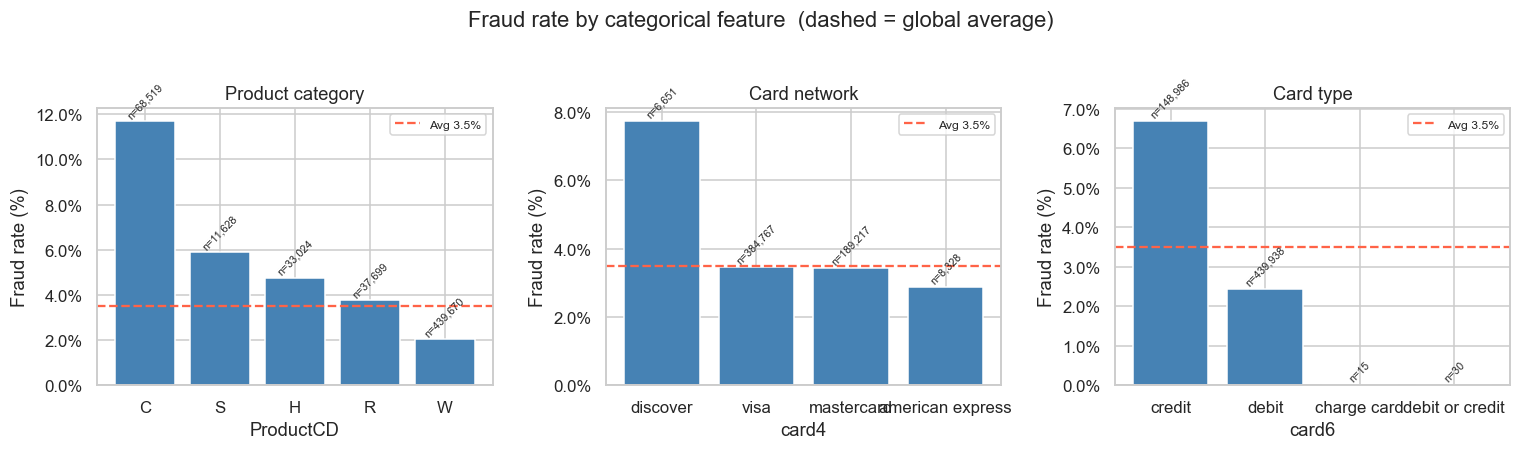

In [7]:
# ── Fraud rate by categorical features ───────────────────────────
cat_features = {
    "ProductCD": "Product category",
    "card4":     "Card network",
    "card6":     "Card type",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, title) in zip(axes, cat_features.items()):
    stats = (
        trans.groupby(col)["isFraud"]
        .agg(fraud_rate="mean", count="count")
        .sort_values("fraud_rate", ascending=False)
        .reset_index()
    )
    bars = ax.bar(stats[col].astype(str), stats["fraud_rate"] * 100,
                  color="steelblue", edgecolor="white")
    ax.axhline(fraud_rate * 100, color="tomato", linewidth=1.5,
               linestyle="--", label=f"Avg {fraud_rate:.1%}")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Fraud rate (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    ax.legend(fontsize=8)
    for bar, row in zip(bars, stats.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"n={row.count:,}", ha="center", va="bottom", fontsize=7, rotation=45)

plt.suptitle("Fraud rate by categorical feature  (dashed = global average)", y=1.02)
plt.tight_layout()
plt.show()

Features with any missing   : 374 / 395
Features with >50% missing  : 174 / 395

Top 10 most missing:
       pct_missing  n_missing
dist2       0.9363     552913
D7          0.9341     551623
D13         0.8951     528588
D14         0.8947     528353
D12         0.8904     525823
D6          0.8761     517353
D8          0.8731     515614
D9          0.8731     515614
V153        0.8612     508595
V163        0.8612     508595


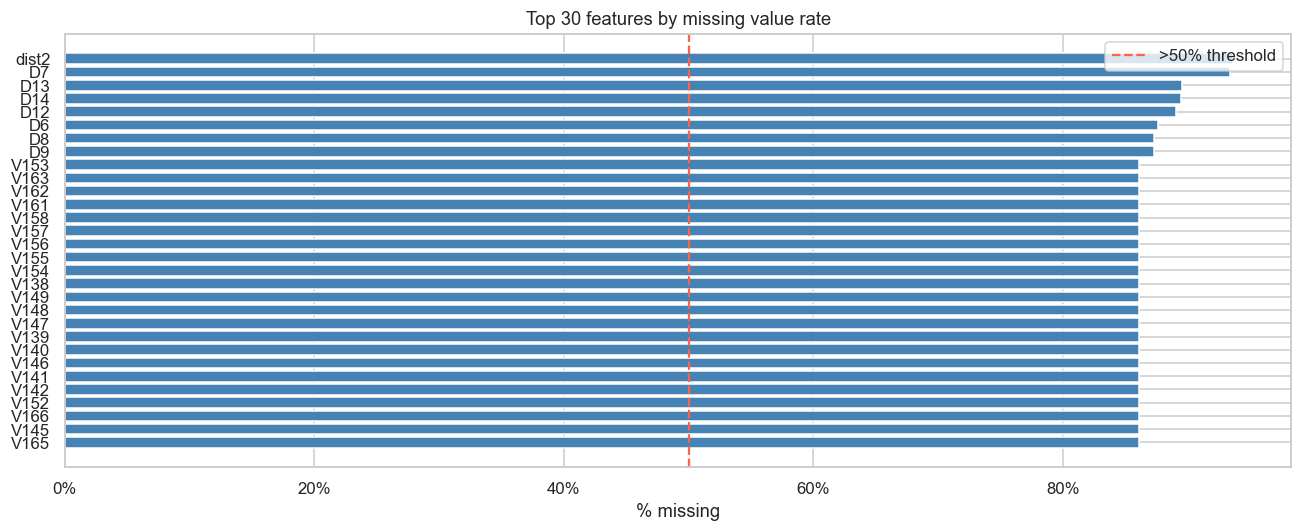

In [8]:
# ── Missing values ───────────────────────────────────────────────
missing = (
    trans.isnull().mean()
    .sort_values(ascending=False)
    .rename("pct_missing")
    .to_frame()
)
missing["n_missing"] = trans.isnull().sum()

n_over_50 = (missing["pct_missing"] > 0.5).sum()
n_any     = (missing["pct_missing"] > 0).sum()

print(f"Features with any missing   : {n_any} / {trans.shape[1]}")
print(f"Features with >50% missing  : {n_over_50} / {trans.shape[1]}")
print()
print("Top 10 most missing:")
print(missing.head(10).to_string())

top30 = missing.head(30)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top30.index[::-1], top30["pct_missing"][::-1] * 100, color="steelblue")
ax.axvline(50, color="tomato", linewidth=1.5, linestyle="--", label=">50% threshold")
ax.set_xlabel("% missing")
ax.set_title("Top 30 features by missing value rate")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
plt.tight_layout()
plt.show()

Transactions with identity data : 144,233  (24.4%)
Transactions without            : 446,307  (75.6%)

Fraud rate WITH identity    : 7.85%
Fraud rate WITHOUT identity : 2.09%
Ratio (with / without)      : 3.75x


/var/folders/_s/fjyv9lpx37s1b52z7j2v78gh0000gn/T/ipykernel_33478/1666418637.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trans["has_identity"] = trans["TransactionID"].isin(ident["TransactionID"])


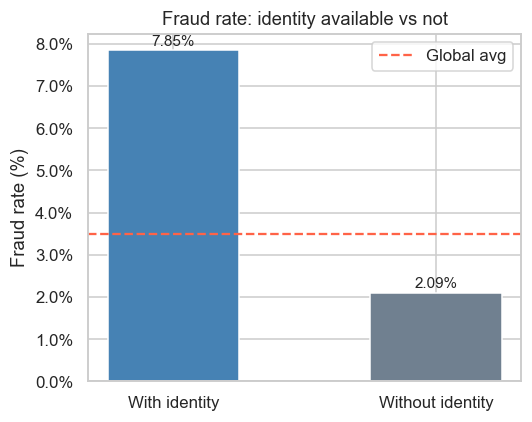

In [9]:
# ── Identity merge coverage ──────────────────────────────────────
trans["has_identity"] = trans["TransactionID"].isin(ident["TransactionID"])

coverage = trans["has_identity"].mean()
print(f"Transactions with identity data : {trans['has_identity'].sum():,}  ({coverage:.1%})")
print(f"Transactions without            : {(~trans['has_identity']).sum():,}  ({1 - coverage:.1%})")
print()

fraud_with    = trans.loc[trans["has_identity"],  "isFraud"].mean()
fraud_without = trans.loc[~trans["has_identity"], "isFraud"].mean()
print(f"Fraud rate WITH identity    : {fraud_with:.2%}")
print(f"Fraud rate WITHOUT identity : {fraud_without:.2%}")
print(f"Ratio (with / without)      : {fraud_with / fraud_without:.2f}x")

fig, ax = plt.subplots(figsize=(5, 4))
labels = ["With identity", "Without identity"]
rates  = [fraud_with * 100, fraud_without * 100]
bars   = ax.bar(labels, rates, color=["steelblue", "slategray"], edgecolor="white", width=0.5)
ax.axhline(fraud_rate * 100, color="tomato", linewidth=1.5, linestyle="--", label="Global avg")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate: identity available vs not")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

# EDA — Key Takeaways

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **3.5% fraud rate, ~28:1 imbalance** | Use AUC-PR as primary metric. ROC-AUC is misleading here. Use `class_weight` in LightGBM, not heavy oversampling. |
| 2 | **Fraud concentrates at higher amounts, but also at very low amounts** | Low-amount fraud = card probing. Log-transform `TransactionAmt` before modeling. |
| 3 | **Fraud rate peaks at night (low-volume hours)** | `hour` is a strong feature. Consider cyclic encoding (sin/cos) to preserve periodicity. |
| 4 | **ProductCD and card type show meaningful fraud rate variation** | Include as categorical features. LightGBM handles them natively without one-hot encoding. |
| 5 | **174 / 394 features have >50% missing** | Do not impute blindly. LightGBM handles NaN natively. Add `is_missing` indicators only for features where missingness itself is informative (e.g., identity fields). |
| 6 | **Identity data covers ~24% of transactions, with higher fraud rate** | Likely selection bias — identity system activates on suspicious transactions. Treat `has_identity` as a feature. Merge identity at model time, not as a required input. |

In [15]:
import pandas as pd
df = pd.read_parquet("/Users/feliperivas/Desktop/Code/Proyectos/fraud-detection-copilot/data/processed/train_transaction_features.parquet")

freq_cols = [c for c in df.columns if c.endswith("_freq")]
print("Freq columns:", freq_cols)
print()
for col in freq_cols:
    nan_pct = df[col].isna().mean() * 100
    print(f"{col:30s}: {nan_pct:.1f}% NaN")

Freq columns: ['card1_freq', 'card2_freq', 'addr1_freq', 'P_emaildomain_freq', 'R_emaildomain_freq', 'DeviceInfo_freq']

card1_freq                    : 0.4% NaN
card2_freq                    : 1.5% NaN
addr1_freq                    : 11.1% NaN
P_emaildomain_freq            : 16.0% NaN
R_emaildomain_freq            : 76.8% NaN
DeviceInfo_freq               : 80.0% NaN
